# Data Outlier Audit

This notebook audits seeded benchmark parameter datasets for distribution drift, missing values, duplicates, and numeric outliers before full training.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
ROOT = Path("..").resolve()
DATASETS = {
    "train": ROOT / "data/static/scenario_parameter_records_seeded_train.json",
    "val": ROOT / "data/static/scenario_parameter_records_seeded_val.json",
    "holdout": ROOT / "data/static/scenario_parameter_records_seeded_holdout.json",
}
NUMERIC_COLUMNS = [
    "base_spread_prob",
    "wind_strength",
    "spread_rate_1h_m",
    "spread_score",
    "weather_score",
    "cffdrs_dryness_score",
    "size_factor",
    "fire_type_factor",
    "fuel_factor",
    "rain_factor",
]

In [2]:
def load_records(path: Path, split_name: str) -> pd.DataFrame:
    payload = json.loads(path.read_text())
    records = payload.get("records", []) if isinstance(payload, dict) else payload
    frame = pd.DataFrame(records)
    frame["split_source"] = split_name
    return frame

frames = [load_records(path, split) for split, path in DATASETS.items()]
df = pd.concat(frames, ignore_index=True)
df.head()

,record_id,fire_id,source,province,year,split,base_spread_prob,severity_bucket,wind_direction,wind_strength,spread_rate_1h_m,spread_score,weather_score,cffdrs_dryness_score,size_factor,fire_type_factor,fuel_factor,rain_factor,observed_spread_rate_m_min,assessment_hectares,fire_type,fuel_type,record_quality_flag,ignition_seed,layout_seed,split_source
0,AB-2008-MWF074__20080703,AB-2008-MWF074,AB_HISTORICAL_WILDFIRE,AB,2008,train,0.1792,high,S,0.1625,6000.0,0.7736,0.4535,0.0,0.9500,1.00,1.12,1.0,100.0,0.50,surface,C2,measured,14443855870861270751,1.127873e+19,train
1,AB-2018-SWF158__20180901,AB-2018-SWF158,AB_HISTORICAL_WILDFIRE,AB,2018,train,0.1571,medium,NW,0.1625,4260.0,0.6504,0.2518,0.0,0.9500,1.00,1.00,1.0,71.0,0.01,surface,O1b,measured,10198127025334700556,1.445778e+19,train
2,AB-2012-MWF047__20120710,AB-2012-MWF047,AB_HISTORICAL_WILDFIRE,AB,2012,train,0.1797,high,W,0.1625,4200.0,0.7759,0.4640,0.0,0.9500,1.00,1.12,1.0,70.0,0.30,surface,C2,measured,8000671072565187824,8.493056e+17,train
3,AB-2014-GWF044__20140715,AB-2014-GWF044,AB_HISTORICAL_WILDFIRE,AB,2014,train,0.2200,high,SW,0.2625,3900.0,1.0000,0.5501,0.0,1.0250,1.18,1.12,1.0,65.0,1000.00,crown,C3,measured,15167517599069789484,1.618321e+19,train
4,AB-2017-CWF254__20171017,AB-2017-CWF254,AB_HISTORICAL_WILDFIRE,AB,2017,train,0.2194,high,W,0.6000,3600.0,0.9966,0.7679,0.0,0.9507,1.18,1.12,1.0,60.0,10.00,crown,C3,measured,2787351251254423658,1.730736e+19,train


In [3]:
summary = {
    "rows_total": int(len(df)),
    "rows_by_split_source": df["split_source"].value_counts(dropna=False).to_dict(),
    "rows_by_split_field": df["split"].value_counts(dropna=False).to_dict(),
    "unique_record_id": int(df["record_id"].nunique(dropna=True)),
    "duplicate_record_id_count": int(df.duplicated(subset=["record_id"]).sum()),
    "duplicate_fire_id_count": int(df.duplicated(subset=["fire_id"]).sum()),
}
summary

{'rows_total': 19246,
 'rows_by_split_source': {'train': 18252, 'val': 993, 'holdout': 1},
 'rows_by_split_field': {'train': 18252, 'val': 993, 'holdout': 1},
 'unique_record_id': 19246,
 'duplicate_record_id_count': 0,
 'duplicate_fire_id_count': 0}

In [4]:
required = [
    "record_id",
    "split",
    "base_spread_prob",
    "severity_bucket",
    "wind_direction",
    "wind_strength",
    "ignition_seed",
    "layout_seed",
]
null_counts = df[required].isna().sum().sort_values(ascending=False)
null_counts

record_id           0
split               0
base_spread_prob    0
severity_bucket     0
wind_direction      0
wind_strength       0
ignition_seed       0
layout_seed         0
dtype: int64

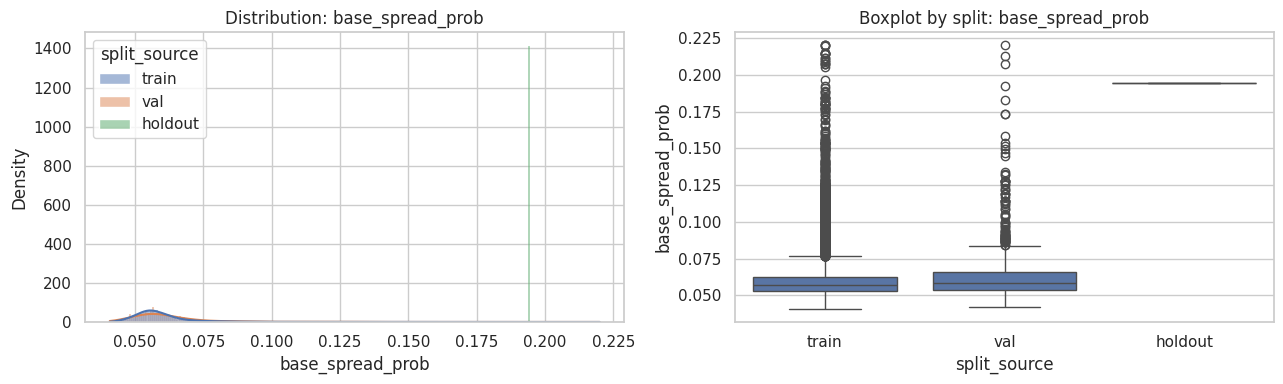

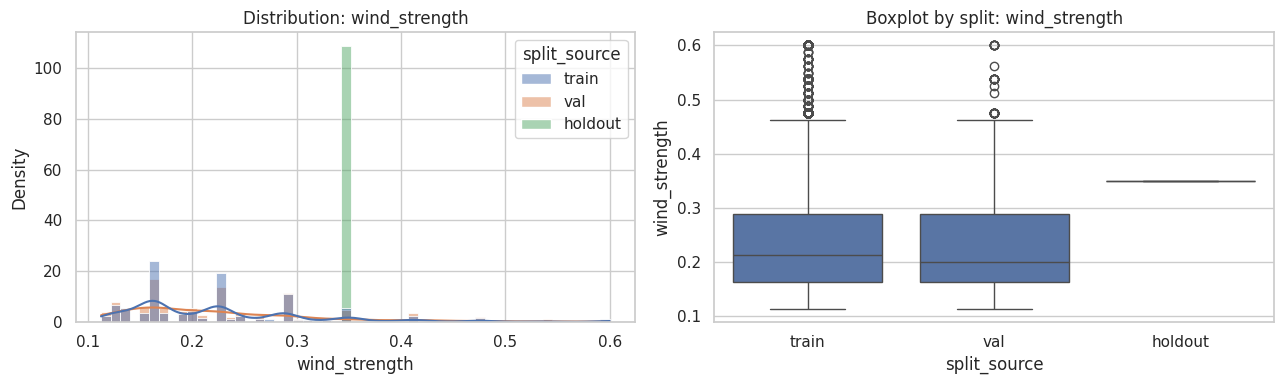

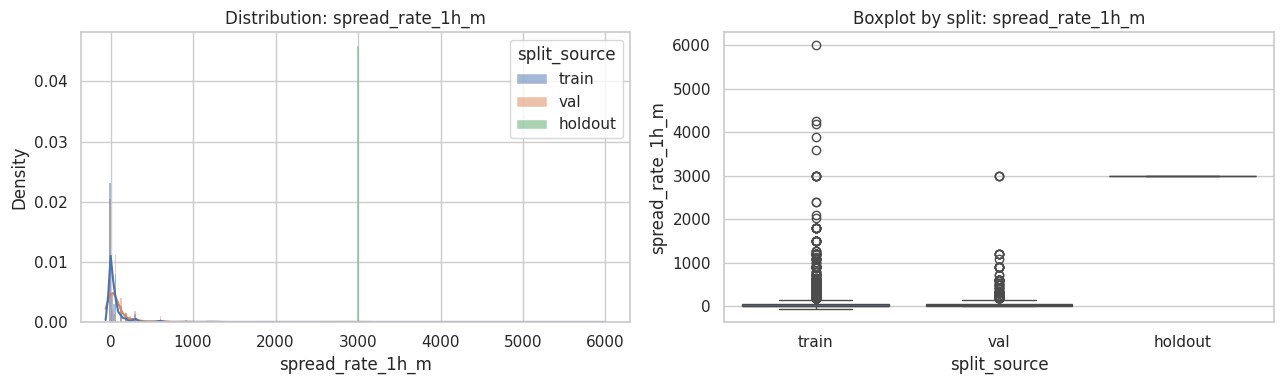

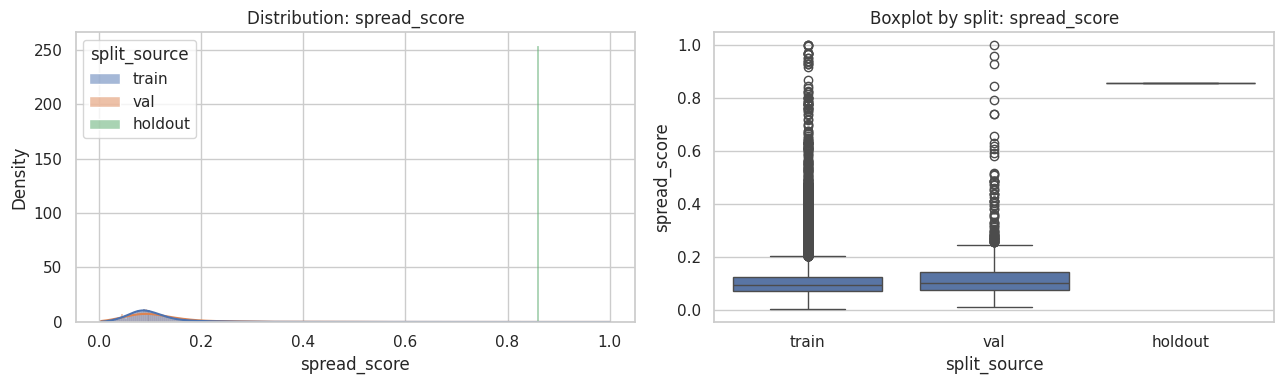

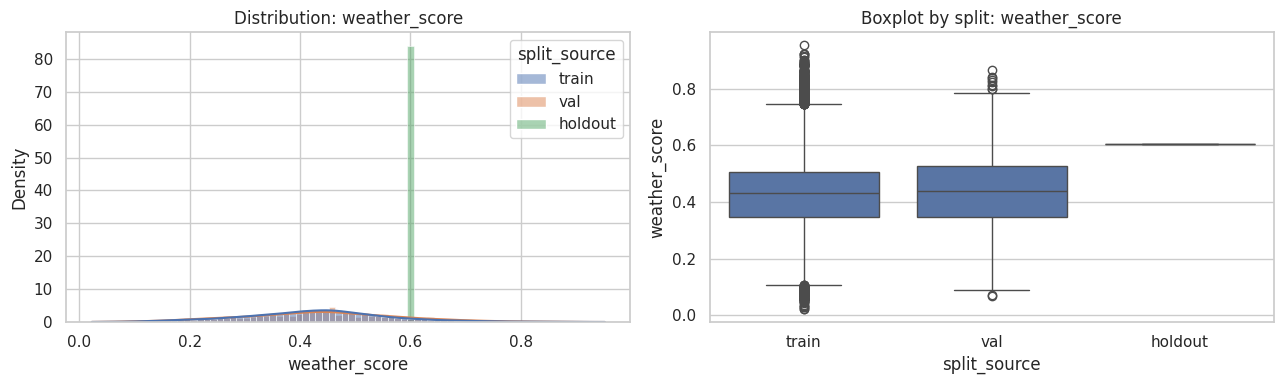

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

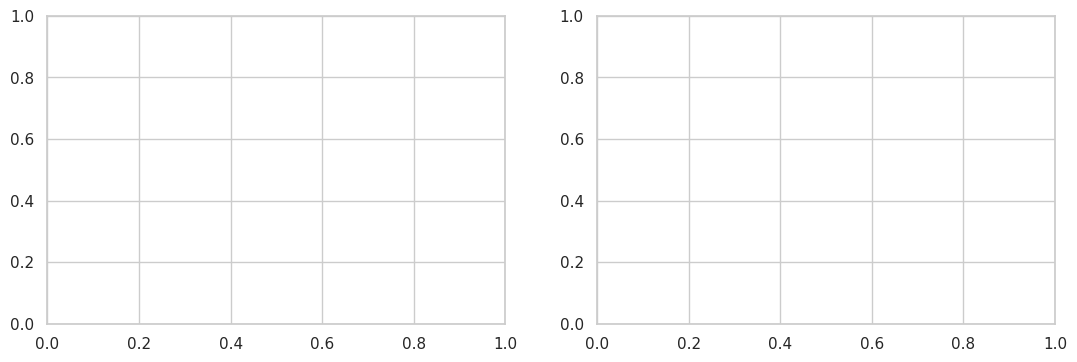

In [5]:
for col in NUMERIC_COLUMNS:
    if col in df.columns:
        fig, ax = plt.subplots(1, 2, figsize=(13, 4))
        sns.histplot(data=df, x=col, hue="split_source", kde=True, ax=ax[0], stat="density", common_norm=False)
        sns.boxplot(data=df, x="split_source", y=col, ax=ax[1])
        ax[0].set_title(f"Distribution: {col}")
        ax[1].set_title(f"Boxplot by split: {col}")
        plt.tight_layout()
        plt.show()


sns.histplot(
    data=df,
    x=col,
    hue="split_source",
    kde=False,   # 🔥 turn this off
    ax=ax[0],
    stat="density",
    common_norm=False
)

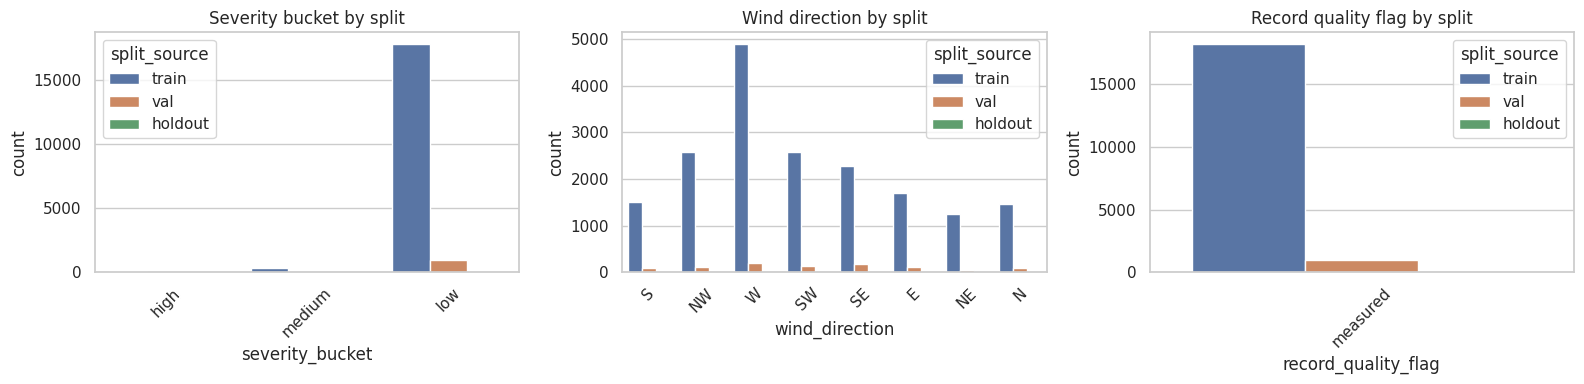

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x="severity_bucket", hue="split_source", ax=axes[0])
axes[0].set_title("Severity bucket by split")
sns.countplot(data=df, x="wind_direction", hue="split_source", ax=axes[1])
axes[1].set_title("Wind direction by split")
sns.countplot(data=df, x="record_quality_flag", hue="split_source", ax=axes[2])
axes[2].set_title("Record quality flag by split")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [7]:
def iqr_outlier_mask(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0 or np.isnan(iqr):
        return pd.Series(False, index=series.index)
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return (series < lo) | (series > hi)

outlier_flags = pd.DataFrame(index=df.index)
for col in NUMERIC_COLUMNS:
    if col in df.columns:
        outlier_flags[col] = iqr_outlier_mask(pd.to_numeric(df[col], errors="coerce"))

df_outliers = df[outlier_flags.any(axis=1)].copy()
df_outliers["outlier_feature_count"] = outlier_flags.sum(axis=1)
outlier_summary = outlier_flags.sum().sort_values(ascending=False)
outlier_summary

spread_rate_1h_m        1926
base_spread_prob        1372
spread_score            1366
wind_strength            728
weather_score            367
cffdrs_dryness_score       0
size_factor                0
fire_type_factor           0
fuel_factor                0
rain_factor                0
dtype: int64

In [8]:
cols = ["record_id", "fire_id", "split", "split_source", "severity_bucket", "wind_direction", "outlier_feature_count"]
numeric_present = [c for c in NUMERIC_COLUMNS if c in df_outliers.columns]
display(df_outliers[cols + numeric_present].sort_values("outlier_feature_count", ascending=False).head(50))

,record_id,fire_id,split,split_source,severity_bucket,wind_direction,outlier_feature_count,base_spread_prob,wind_strength,spread_rate_1h_m,spread_score,weather_score,cffdrs_dryness_score,size_factor,fire_type_factor,fuel_factor,rain_factor
1081,AB-2011-WWF021__20110514,AB-2011-WWF021,train,train,low,NW,5,0.0819,0.6000,240.0,0.2326,0.8912,0.0,0.9501,0.80,1.06,1.0
455,AB-2018-SWF053__20180528,AB-2018-SWF053,train,train,medium,W,5,0.1140,0.6000,360.0,0.4109,0.8345,0.0,0.9501,1.18,1.12,1.0
1097,AB-2006-LWF125__20060705,AB-2006-LWF125,train,train,low,S,5,0.0988,0.4750,240.0,0.3268,0.7560,0.0,0.9501,1.18,1.12,1.0
18361,AB-2023-CWF003__20230501,AB-2023-CWF003,val,val,low,E,5,0.0905,0.5375,240.0,0.2805,0.8429,0.0,0.9500,1.00,1.06,1.0
18256,AB-2023-WWF023__20230505,AB-2023-WWF023,val,val,high,SE,5,0.1924,0.4750,1200.0,0.8465,0.7974,0.0,0.9515,1.18,1.12,1.0
845,AB-2021-RWF070__20210723,AB-2021-RWF070,train,train,low,SE,5,0.0846,0.4750,300.0,0.2477,0.7819,0.0,0.9500,0.80,1.12,1.0
215,AB-2011-SWF065__20110514,AB-2011-SWF065,train,train,medium,SE,5,0.1400,0.6000,600.0,0.5557,0.9010,0.0,0.9504,1.18,1.12,1.0
328,AB-2011-LWF119__20110512,AB-2011-LWF119,train,train,medium,SE,5,0.1110,0.6000,600.0,0.3944,0.7720,0.0,0.9500,1.00,1.00,1.0
521,AB-2010-MWF069__20100724,AB-2010-MWF069,train,train,medium,SW,5,0.1047,0.5000,300.0,0.3595,0.7572,0.0,0.9509,1.18,1.12,1.0
679,AB-2013-GWF012__20130512,AB-2013-GWF012,train,train,medium,W,5,0.1094,0.6000,300.0,0.3855,0.8580,0.0,0.9502,1.18,1.12,1.0


In [9]:
output_dir = ROOT / "outputs/data_audit"
output_dir.mkdir(parents=True, exist_ok=True)

(output_dir / "summary_stats.json").write_text(json.dumps(summary, indent=2))
df.describe(include="all", datetime_is_numeric=True).to_csv(output_dir / "describe_all.csv")
df_outliers.to_csv(output_dir / "outlier_rows.csv", index=False)
outlier_summary.to_csv(output_dir / "outlier_feature_counts.csv")
print(f"Wrote data audit artifacts to {output_dir}")

TypeError: NDFrame.describe() got an unexpected keyword argument 'datetime_is_numeric'

## Go/No-Go Checklist

- No missing required fields in seeded split datasets
- No unexpected split leakage between `split_source` and `split`
- Numeric ranges are physically plausible (`base_spread_prob` in [0,1], `wind_strength` in [0,1])
- Outliers are explainable and not caused by parsing/ETL bugs
- Severity and wind distributions are plausible across train/val/holdout